# LazyPredict Analysis for Help Desk Ticket Data (v3 - Correct Order)

**Wichtig: Korrekte Reihenfolge zur Vermeidung von Data Leakage:**
1. Train-Test-Split
2. Imputer fit auf Train → transform auf Train & Test
3. Scaler fit auf Train → transform auf Train & Test

## 1. Setup & Installation

In [ ]:
# Install required packages
!pip install lazypredict -q
!pip install xgboost lightgbm -q

In [7]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

# LazyPredict
from lazypredict.Supervised import LazyClassifier, LazyRegressor

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer

# Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("✓ All libraries loaded!")

✓ All libraries loaded!


## 2. Load Data

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

ModuleNotFoundError: No module named 'google.colab'

In [8]:
# Define data directory - ADJUST THIS PATH TO YOUR DATA
#directory = Path('/content/drive/MyDrive/Colab Notebooks/nov25_bds_int_helpdesk/data/raw')
directory  = Path('../data/raw')

# Load datasets
dfi = pd.read_csv(directory / "issues.csv", low_memory=False)

print(f"✓ Issues dataset loaded: {dfi.shape[0]:,} rows, {dfi.shape[1]} columns")
print(f"\nColumns available:")
print(dfi.columns.tolist())

✓ Issues dataset loaded: 66,691 rows, 58 columns

Columns available:
['id', 'started', 'ended', 'issue_num', 'issue_proj', 'issue_reporter', 'issue_assignee', 'issue_contr_count', 'issue_type', 'issue_priority', 'issue_created', 'issue_resolution_date', 'issue_resolution', 'issue_status', 'issue_comments_count', 'last_change_date', 'wf_in_review', 'wfe_in_review', 'wf_deployment', 'wfe_deployment', 'wf_resolved', 'wfe_resolved', 'wf_open', 'wfe_open', 'wf_monitoring', 'wfe_monitoring', 'wf_done', 'wfe_done', 'wf_pending_customer_approval', 'wfe_pending_customer_approval', 'wf_rejected', 'wfe_rejected', 'wf_testing_monitoring', 'wfe_testing_monitoring', 'wf_in_progress', 'wfe_in_progress', 'wf_reopened', 'wfe_reopened', 'wf_to_do', 'wfe_to_do', 'wf_validation', 'wfe_validation', 'wf_resolved_under_monitoring', 'wfe_resolved_under_monitoring', 'wf_closed', 'wfe_closed', 'wf_waiting', 'wfe_waiting', 'wf_cancelled', 'wfe_cancelled', 'wf_under_review', 'wfe_under_review', 'wf_approved', 'wf

In [9]:
# Quick look at the data
dfi.head(3)

,id,started,ended,issue_num,issue_proj,issue_reporter,issue_assignee,issue_contr_count,issue_type,issue_priority,issue_created,issue_resolution_date,issue_resolution,issue_status,issue_comments_count,last_change_date,wf_in_review,wfe_in_review,wf_deployment,wfe_deployment,wf_resolved,wfe_resolved,wf_open,wfe_open,wf_monitoring,wfe_monitoring,wf_done,wfe_done,wf_pending_customer_approval,wfe_pending_customer_approval,wf_rejected,wfe_rejected,wf_testing_monitoring,wfe_testing_monitoring,wf_in_progress,wfe_in_progress,wf_reopened,wfe_reopened,wf_to_do,wfe_to_do,wf_validation,wfe_validation,wf_resolved_under_monitoring,wfe_resolved_under_monitoring,wf_closed,wfe_closed,wf_waiting,wfe_waiting,wf_cancelled,wfe_cancelled,wf_under_review,wfe_under_review,wf_approved,wfe_approved,wf_pending_deployment,wfe_pending_deployment,wf_total_time,processing_steps
0,11887.00,2016-01-06 08:23:43+00:00,2016-01-06 08:56:55+00:00,186.00,d1z0,4olg,NaN,1.00,Ticket,Medium,2016-01-06 08:23:43+00:00,2016-01-06 08:56:55+00:00,Done,done,1,2016-04-02 12:20:21+00:00,NaN,0,NaN,0,NaN,0,29.00,1,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,1963.00,1,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,1992.00,2
1,11890.00,2016-01-11 10:06:19+00:00,2016-01-12 12:30:23+00:00,190.00,d1z0,4olg,NaN,1.00,Ticket,Medium,2016-01-11 10:06:19+00:00,2016-01-12 12:30:23+00:00,Done,done,0,2016-04-02 12:20:21+00:00,NaN,0,NaN,0,NaN,0,44.00,1,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,95000.00,1,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,95044.00,2
2,11904.00,2016-01-21 07:28:20+00:00,2016-01-26 08:21:47+00:00,198.00,d1z0,4ohk,4ohk,1.00,Ticket,Medium,2016-01-21 07:28:20+00:00,2016-01-26 08:21:47+00:00,Done,done,0,2016-04-02 12:20:21+00:00,NaN,0,NaN,0,NaN,0,8.00,1,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,435199.00,1,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,435207.00,2


## 3. Data Preprocessing

In [10]:
# Create working copy
df = dfi.copy()

# Convert date columns (if they exist)
date_cols = ['started', 'ended', 'issue_created', 'issue_resolution_date', 'last_change_date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f"✓ Converted {col} to datetime")

# Apply temporal filter (after 2015-07-01)
if 'issue_created' in df.columns:
    if df['issue_created'].dt.tz is not None:
        df['issue_created'] = df['issue_created'].dt.tz_localize(None)
    
    cutoff_date = pd.Timestamp("2015-07-01")
    before_filter = len(df)
    df = df[df['issue_created'] >= cutoff_date]
    print(f"\n✓ Temporal filter applied: {before_filter:,} → {len(df):,} rows")

# Clean issue_type
if 'issue_type' in df.columns:
    df['issue_type'] = df['issue_type'].replace({'Sub-task': 'Subtask'})
    print(f"✓ Cleaned issue_type")

# Create proj_type from issue_proj
if 'issue_proj' in df.columns:
    proj = df['issue_proj'].astype('string').str.strip()
    df['proj_type'] = 'internal'
    df.loc[proj.str.match(r'^C\d{2}.+', na=False), 'proj_type'] = 'external'
    print(f"✓ Created proj_type column")

print(f"\n✓ Final dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

✓ Converted started to datetime
✓ Converted ended to datetime
✓ Converted issue_created to datetime
✓ Converted issue_resolution_date to datetime
✓ Converted last_change_date to datetime

✓ Temporal filter applied: 66,691 → 30,381 rows
✓ Cleaned issue_type
✓ Created proj_type column

✓ Final dataset: 30,381 rows, 59 columns


## 4. Feature Engineering

In [11]:
# Dynamically detect available features

# All possible numeric features
possible_numeric = [
    'issue_contr_count', 'issue_comments_count', 'processing_steps',
    'wf_open', 'wf_in_progress', 'wf_waiting', 'wf_resolved',
    'wf_validation', 'wf_deployment', 'wf_monitoring', 'wf_done',
    'wf_pending_customer_approval', 'wf_rejected', 'wf_testing_monitoring',
    'wf_reopened', 'wf_to_do', 'wf_closed', 'wf_cancelled',
    'wf_under_review', 'wf_approved', 'wf_pending_deployment',
    'wf_in_review', 'wf_resolved_under_monitoring', 'wf_total_time'
]

# All possible categorical features
possible_categorical = ['issue_type', 'proj_type', 'issue_priority']

# Filter to only columns that ACTUALLY EXIST
numeric_features = [col for col in possible_numeric if col in df.columns]
categorical_features = [col for col in possible_categorical if col in df.columns]

print(f"✓ Found {len(numeric_features)} numeric features:")
print(f"  {numeric_features}")
print(f"\n✓ Found {len(categorical_features)} categorical features:")
print(f"  {categorical_features}")

✓ Found 24 numeric features:
  ['issue_contr_count', 'issue_comments_count', 'processing_steps', 'wf_open', 'wf_in_progress', 'wf_waiting', 'wf_resolved', 'wf_validation', 'wf_deployment', 'wf_monitoring', 'wf_done', 'wf_pending_customer_approval', 'wf_rejected', 'wf_testing_monitoring', 'wf_reopened', 'wf_to_do', 'wf_closed', 'wf_cancelled', 'wf_under_review', 'wf_approved', 'wf_pending_deployment', 'wf_in_review', 'wf_resolved_under_monitoring', 'wf_total_time']

✓ Found 3 categorical features:
  ['issue_type', 'proj_type', 'issue_priority']


In [12]:
def prepare_features_safe(df, numeric_cols, categorical_cols):
    """
    Safely prepare features for ML.
    """
    feature_df = df.copy()
    final_features = []
    label_encoders = {}
    
    # Process numeric features
    for col in numeric_cols:
        if col in feature_df.columns:
            feature_df[col] = pd.to_numeric(feature_df[col], errors='coerce')
            final_features.append(col)
    
    # Process categorical features (encode them)
    for col in categorical_cols:
        if col in feature_df.columns:
            le = LabelEncoder()
            feature_df[col] = feature_df[col].fillna('Unknown').astype(str)
            feature_df[f'{col}_encoded'] = le.fit_transform(feature_df[col])
            label_encoders[col] = le
            final_features.append(f'{col}_encoded')
    
    print(f"✓ Prepared {len(final_features)} features total")
    return feature_df, final_features, label_encoders

df_processed, feature_cols, encoders = prepare_features_safe(
    df, numeric_features, categorical_features
)

print(f"\nFinal feature list: {feature_cols}")

✓ Prepared 27 features total

Final feature list: ['issue_contr_count', 'issue_comments_count', 'processing_steps', 'wf_open', 'wf_in_progress', 'wf_waiting', 'wf_resolved', 'wf_validation', 'wf_deployment', 'wf_monitoring', 'wf_done', 'wf_pending_customer_approval', 'wf_rejected', 'wf_testing_monitoring', 'wf_reopened', 'wf_to_do', 'wf_closed', 'wf_cancelled', 'wf_under_review', 'wf_approved', 'wf_pending_deployment', 'wf_in_review', 'wf_resolved_under_monitoring', 'wf_total_time', 'issue_type_encoded', 'proj_type_encoded', 'issue_priority_encoded']


## 5. Helper Function: Correct Preprocessing Pipeline

**WICHTIG: Korrekte Reihenfolge!**
1. Train-Test-Split ZUERST
2. Imputer fit NUR auf Train
3. Scaler fit NUR auf Train

In [13]:
def prepare_train_test_properly(X, y, test_size=0.2, random_state=42, stratify=None):
    """
    Korrekte Reihenfolge:
    1. Train-Test-Split
    2. Imputer fit auf Train, transform auf beide
    3. Scaler fit auf Train, transform auf beide
    
    Returns: X_train, X_test, y_train, y_test (alle preprocessed)
    """
    
    # ============================================
    # SCHRITT 1: Train-Test-Split ZUERST!
    # ============================================
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=test_size, 
        random_state=random_state,
        stratify=stratify
    )
    
    print(f"1. Train-Test-Split:")
    print(f"   Train: {len(X_train):,} samples")
    print(f"   Test:  {len(X_test):,} samples")
    
    # ============================================
    # SCHRITT 2: Imputer - fit NUR auf Train!
    # ============================================
    imputer = SimpleImputer(strategy='median')
    
    # fit_transform auf Train
    X_train_imputed = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )
    
    # NUR transform auf Test (NICHT fit!)
    X_test_imputed = pd.DataFrame(
        imputer.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    )
    
    print(f"2. Imputer: fit auf Train, transform auf beide ✓")
    
    # ============================================
    # SCHRITT 3: Scaler - fit NUR auf Train!
    # ============================================
    scaler = RobustScaler()
    
    # fit_transform auf Train
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_imputed),
        columns=X_train_imputed.columns,
        index=X_train_imputed.index
    )
    
    # NUR transform auf Test (NICHT fit!)
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_imputed),
        columns=X_test_imputed.columns,
        index=X_test_imputed.index
    )
    
    print(f"3. Scaler: fit auf Train, transform auf beide ✓")
    print(f"\n✓ Preprocessing complete (no data leakage)")
    
    return X_train_scaled, X_test_scaled, y_train, y_test, imputer, scaler

## 6. LazyRegressor - Predict Total Workflow Time

In [14]:
# Check regression target
regression_target = 'wf_total_time'

if regression_target not in df_processed.columns:
    print(f"⚠ Target '{regression_target}' not found!")
else:
    print(f"✓ Target '{regression_target}' found")
    print(f"  Non-null: {df_processed[regression_target].notna().sum():,}")
    print(f"  Min: {df_processed[regression_target].min():,.0f}")
    print(f"  Max: {df_processed[regression_target].max():,.0f}")

✓ Target 'wf_total_time' found
  Non-null: 30,381
  Min: 0
  Max: 176,135,646


In [15]:
# Prepare regression data
if regression_target in df_processed.columns:
    # Remove target from features!
    reg_features = [f for f in feature_cols if f != regression_target]
    
    # Get valid rows
    reg_df = df_processed[df_processed[regression_target].notna()].copy()
    
    # Filter features with data
    valid_features = [f for f in reg_features if reg_df[f].notna().sum() > 0]
    
    print(f"Using {len(valid_features)} features")
    print(f"Dataset: {len(reg_df):,} samples")
    
    # Create X and y (log transform target)
    X_reg = reg_df[valid_features].copy()
    y_reg = np.log1p(reg_df[regression_target])

Using 26 features
Dataset: 30,381 samples


In [16]:
# CORRECT ORDER: Split → Impute → Scale
print("="*50)
print("REGRESSION: Correct Preprocessing Pipeline")
print("="*50)

X_train_reg, X_test_reg, y_train_reg, y_test_reg, imputer_reg, scaler_reg = \
    prepare_train_test_properly(X_reg, y_reg, test_size=0.2, random_state=42)

REGRESSION: Correct Preprocessing Pipeline
1. Train-Test-Split:
   Train: 24,304 samples
   Test:  6,077 samples
2. Imputer: fit auf Train, transform auf beide ✓
3. Scaler: fit auf Train, transform auf beide ✓

✓ Preprocessing complete (no data leakage)


In [17]:
%%time
# Run LazyRegressor
print("Running LazyRegressor...\n")

reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
reg_models, reg_predictions = reg.fit(X_train_reg, X_test_reg, y_train_reg, y_test_reg)

print("\n✓ Done!")

Running LazyRegressor...



  0%|          | 0/42 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000953 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3010
[LightGBM] [Info] Number of data points in the train set: 24304, number of used features: 23
[LightGBM] [Info] Start training from score 13.369191

✓ Done!
CPU times: user 38min 15s, sys: 51.4 s, total: 39min 6s
Wall time: 3min 26s


In [18]:
# Display regression results
print("\n" + "="*60)
print("📊 REGRESSION RESULTS - Total Workflow Time (Top 20)")
print("="*60)
display(reg_models.head(20))


📊 REGRESSION RESULTS - Total Workflow Time (Top 20)


,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
LGBMRegressor,0.99,0.99,0.37,0.15
HistGradientBoostingRegressor,0.98,0.98,0.42,0.42
RandomForestRegressor,0.98,0.98,0.45,9.87
BaggingRegressor,0.98,0.98,0.46,1.01
XGBRegressor,0.98,0.98,0.46,0.18
ExtraTreesRegressor,0.98,0.98,0.46,5.32
DecisionTreeRegressor,0.97,0.97,0.58,0.22
ExtraTreeRegressor,0.94,0.94,0.75,0.12
GradientBoostingRegressor,0.92,0.92,0.92,2.37


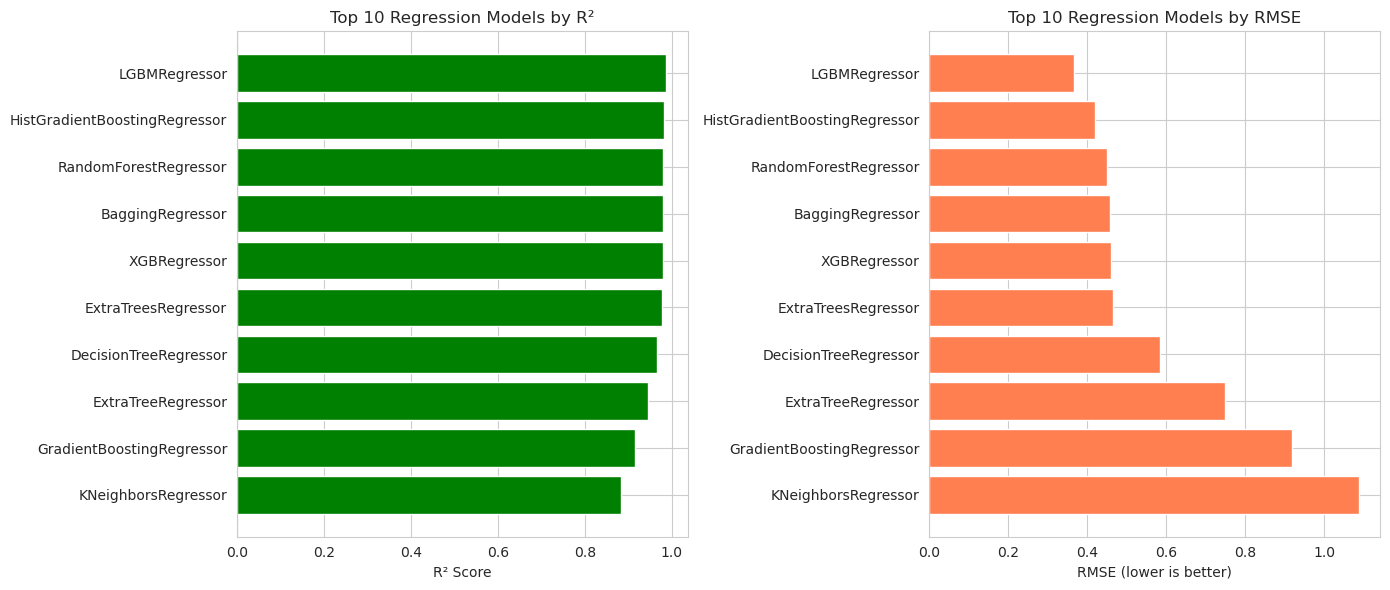

In [19]:
# Visualize regression results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# R² Score
top_reg = reg_models.head(10).sort_values('R-Squared', ascending=True)
colors = ['green' if x > 0 else 'red' for x in top_reg['R-Squared']]
axes[0].barh(top_reg.index, top_reg['R-Squared'], color=colors)
axes[0].set_xlabel('R² Score')
axes[0].set_title('Top 10 Regression Models by R²')
axes[0].axvline(x=0, color='black', linestyle='--', alpha=0.5)

# RMSE
top_rmse = reg_models.head(10).sort_values('RMSE', ascending=False)
axes[1].barh(top_rmse.index, top_rmse['RMSE'], color='coral')
axes[1].set_xlabel('RMSE (lower is better)')
axes[1].set_title('Top 10 Regression Models by RMSE')

plt.tight_layout()
plt.show()

## 7. LazyClassifier - Predict Issue Priority

In [20]:
# Check classification target
classification_target = 'issue_priority'

if classification_target not in df_processed.columns:
    print(f"⚠ Target '{classification_target}' not found!")
else:
    print(f"✓ Target '{classification_target}' found")
    print(f"\nValue counts:")
    print(df_processed[classification_target].value_counts())

✓ Target 'issue_priority' found

Value counts:
issue_priority
Medium     12678
unknown    10471
High        4155
Highest     1915
Blocker      641
Low          472
Lowest        49
Name: count, dtype: int64


In [21]:
# Prepare classification data
if classification_target in df_processed.columns:
    # Get valid rows
    clf_df = df_processed[df_processed[classification_target].notna()].copy()
    clf_df = clf_df[clf_df[classification_target] != 'unknown']
    
    print(f"Dataset: {len(clf_df):,} samples")
    
    # Encode target
    le_priority = LabelEncoder()
    y_clf = le_priority.fit_transform(clf_df[classification_target])
    
    print(f"\nClasses: {le_priority.classes_}")
    
    # Features (exclude priority)
    clf_features = [f for f in feature_cols if 'priority' not in f.lower()]
    valid_clf_features = [f for f in clf_features if clf_df[f].notna().sum() > 0]
    
    X_clf = clf_df[valid_clf_features].copy()
    print(f"Using {len(valid_clf_features)} features")

Dataset: 19,910 samples

Classes: ['Blocker' 'High' 'Highest' 'Low' 'Lowest' 'Medium']
Using 24 features


In [22]:
# CORRECT ORDER: Split → Impute → Scale (with stratify for classification)
print("="*50)
print("CLASSIFICATION (Priority): Correct Preprocessing Pipeline")
print("="*50)

X_train_clf, X_test_clf, y_train_clf, y_test_clf, imputer_clf, scaler_clf = \
    prepare_train_test_properly(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

CLASSIFICATION (Priority): Correct Preprocessing Pipeline
1. Train-Test-Split:
   Train: 15,928 samples
   Test:  3,982 samples
2. Imputer: fit auf Train, transform auf beide ✓
3. Scaler: fit auf Train, transform auf beide ✓

✓ Preprocessing complete (no data leakage)


In [23]:
%%time
# Run LazyClassifier
print("Running LazyClassifier for Issue Priority...\n")

clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
clf_models, clf_predictions = clf.fit(X_train_clf, X_test_clf, y_train_clf, y_test_clf)

print("\n✓ Done!")

Running LazyClassifier for Issue Priority...



  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000835 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2748
[LightGBM] [Info] Number of data points in the train set: 15928, number of used features: 20
[LightGBM] [Info] Start training from score -3.435558
[LightGBM] [Info] Start training from score -1.566910
[LightGBM] [Info] Start training from score -2.341504
[LightGBM] [Info] Start training from score -3.740940
[LightGBM] [Info] Start training from score -6.012272
[LightGBM] [Info] Start training from score -0.451393

✓ Done!
CPU times: user 2min 7s, sys: 27.1 s, total: 2min 34s
Wall time: 34.9 s


In [24]:
# Display classification results
print("\n" + "="*60)
print("📊 CLASSIFICATION RESULTS - Issue Priority (Top 20)")
print("="*60)
display(clf_models.head(20))


📊 CLASSIFICATION RESULTS - Issue Priority (Top 20)


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
NearestCentroid,0.36,0.36,None,0.43,0.02
ExtraTreesClassifier,0.64,0.27,None,0.62,1.22
DecisionTreeClassifier,0.58,0.27,None,0.58,0.14
RandomForestClassifier,0.66,0.27,None,0.63,1.93
ExtraTreeClassifier,0.58,0.26,None,0.58,0.02
QuadraticDiscriminantAnalysis,0.07,0.26,None,0.08,0.03
GaussianNB,0.03,0.26,None,0.03,0.02
LabelPropagation,0.63,0.26,None,0.61,4.64
LabelSpreading,0.63,0.26,None,0.61,7.57


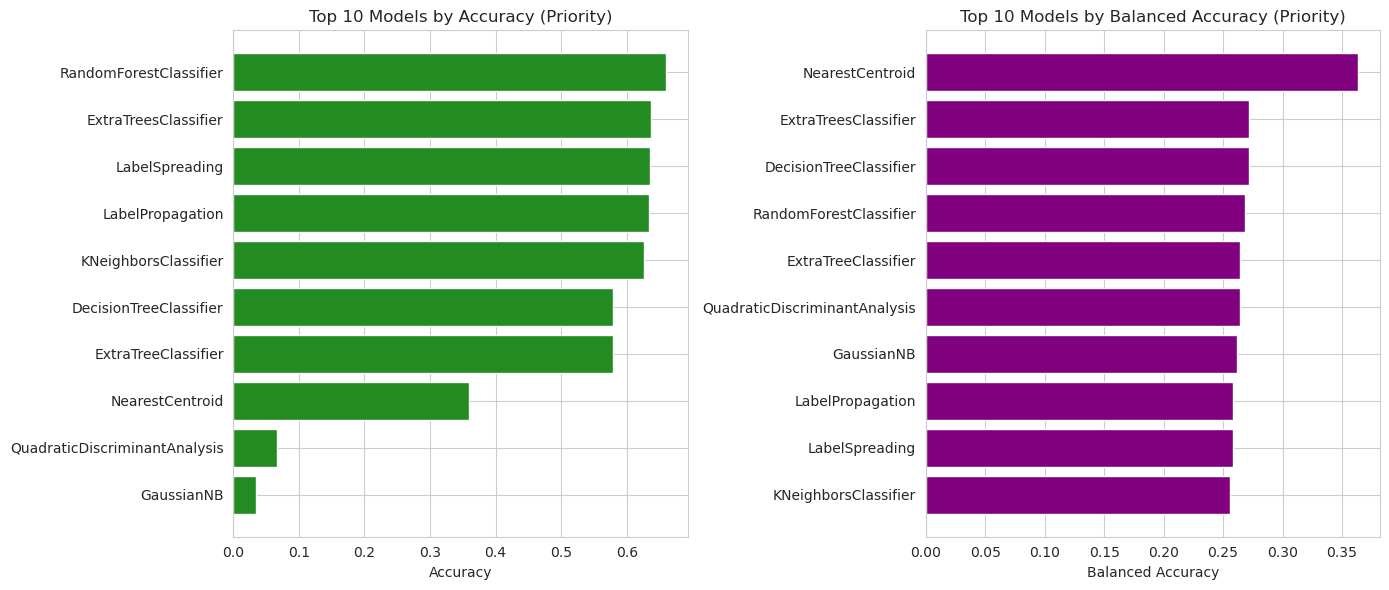

In [25]:
# Visualize classification results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy
top_clf = clf_models.head(10).sort_values('Accuracy', ascending=True)
axes[0].barh(top_clf.index, top_clf['Accuracy'], color='forestgreen')
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Top 10 Models by Accuracy (Priority)')

# Balanced Accuracy
top_bal = clf_models.head(10).sort_values('Balanced Accuracy', ascending=True)
axes[1].barh(top_bal.index, top_bal['Balanced Accuracy'], color='purple')
axes[1].set_xlabel('Balanced Accuracy')
axes[1].set_title('Top 10 Models by Balanced Accuracy (Priority)')

plt.tight_layout()
plt.show()

## 8. LazyClassifier - Predict Issue Resolution

In [26]:
# Prepare resolution classification
target_resolution = 'issue_resolution'

if target_resolution in df_processed.columns:
    clf2_df = df_processed[df_processed[target_resolution].notna()].copy()
    
    print(f"Dataset: {len(clf2_df):,} samples")
    print(f"\nValue counts:")
    print(clf2_df[target_resolution].value_counts())
    
    # Encode target
    le_resolution = LabelEncoder()
    y_clf2 = le_resolution.fit_transform(clf2_df[target_resolution])
    
    # Features
    clf2_features = [f for f in feature_cols if 'resolution' not in f.lower()]
    valid_clf2_features = [f for f in clf2_features if clf2_df[f].notna().sum() > 0]
    
    X_clf2 = clf2_df[valid_clf2_features].copy()
    print(f"\nUsing {len(valid_clf2_features)} features")
else:
    print(f"⚠ Target '{target_resolution}' not found!")

Dataset: 29,559 samples

Value counts:
issue_resolution
Done                27826
Won't Do             1258
Duplicate             390
Cannot Reproduce       85
Name: count, dtype: int64

Using 27 features


In [27]:
# CORRECT ORDER: Split → Impute → Scale
print("="*50)
print("CLASSIFICATION (Resolution): Correct Preprocessing Pipeline")
print("="*50)

X_train_clf2, X_test_clf2, y_train_clf2, y_test_clf2, imputer_clf2, scaler_clf2 = \
    prepare_train_test_properly(X_clf2, y_clf2, test_size=0.2, random_state=42, stratify=y_clf2)

CLASSIFICATION (Resolution): Correct Preprocessing Pipeline
1. Train-Test-Split:
   Train: 23,647 samples
   Test:  5,912 samples
2. Imputer: fit auf Train, transform auf beide ✓
3. Scaler: fit auf Train, transform auf beide ✓

✓ Preprocessing complete (no data leakage)


In [28]:
%%time
# Run LazyClassifier for Resolution
print("Running LazyClassifier for Issue Resolution...\n")

clf2 = LazyClassifier(verbose=0, ignore_warnings=True)
clf2_models, clf2_predictions = clf2.fit(X_train_clf2, X_test_clf2, y_train_clf2, y_test_clf2)

print("\n✓ Done!")

Running LazyClassifier for Issue Resolution...



  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000888 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3255
[LightGBM] [Info] Number of data points in the train set: 23647, number of used features: 24
[LightGBM] [Info] Start training from score -5.851484
[LightGBM] [Info] Start training from score -0.060400
[LightGBM] [Info] Start training from score -4.327988
[LightGBM] [Info] Start training from score -3.157254

✓ Done!
CPU times: user 3min 45s, sys: 54.8 s, total: 4min 40s
Wall time: 52.9 s


In [29]:
# Display results
print("\n" + "="*60)
print("📊 CLASSIFICATION RESULTS - Issue Resolution (Top 20)")
print("="*60)
display(clf2_models.head(20))


📊 CLASSIFICATION RESULTS - Issue Resolution (Top 20)


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
NearestCentroid,0.48,0.45,None,0.62,0.04
DecisionTreeClassifier,0.94,0.44,None,0.94,0.19
ExtraTreeClassifier,0.93,0.44,None,0.93,0.02
ExtraTreesClassifier,0.96,0.42,None,0.95,1.08
BaggingClassifier,0.96,0.42,None,0.95,1.08
LGBMClassifier,0.96,0.42,None,0.95,0.50
RandomForestClassifier,0.96,0.42,None,0.95,2.45
XGBClassifier,0.96,0.41,None,0.95,0.35
KNeighborsClassifier,0.96,0.41,None,0.95,0.10


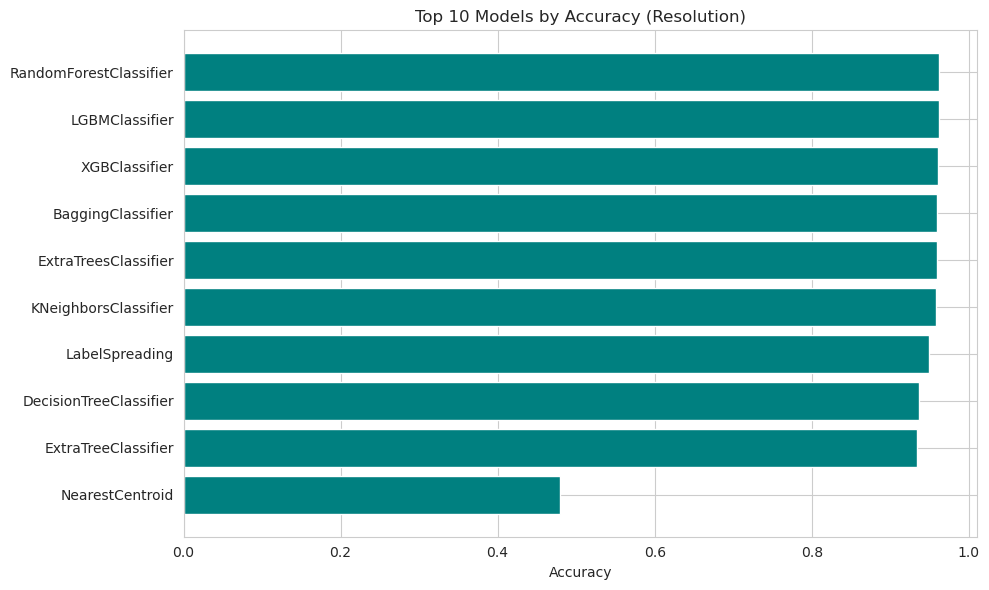

In [30]:
# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
top_clf2 = clf2_models.head(10).sort_values('Accuracy', ascending=True)
ax.barh(top_clf2.index, top_clf2['Accuracy'], color='teal')
ax.set_xlabel('Accuracy')
ax.set_title('Top 10 Models by Accuracy (Resolution)')
plt.tight_layout()
plt.show()

## 9. LazyClassifier - Predict Project Type (Internal vs External)

In [31]:
# Prepare project type classification
target_proj = 'proj_type'

if target_proj in df_processed.columns:
    clf3_df = df_processed[df_processed[target_proj].notna()].copy()
    clf3_df = clf3_df[clf3_df[target_proj] != 'unknown']
    
    print(f"Dataset: {len(clf3_df):,} samples")
    print(f"\nValue counts:")
    print(clf3_df[target_proj].value_counts())
    
    # Encode target
    le_proj = LabelEncoder()
    y_clf3 = le_proj.fit_transform(clf3_df[target_proj])
    
    # Features (exclude proj_type)
    clf3_features = [f for f in feature_cols if 'proj_type' not in f]
    valid_clf3_features = [f for f in clf3_features if clf3_df[f].notna().sum() > 0]
    
    X_clf3 = clf3_df[valid_clf3_features].copy()
    print(f"\nUsing {len(valid_clf3_features)} features")
else:
    print(f"⚠ Target '{target_proj}' not found!")

Dataset: 30,381 samples

Value counts:
proj_type
external    21715
internal     8666
Name: count, dtype: int64

Using 26 features


In [32]:
# CORRECT ORDER: Split → Impute → Scale
print("="*50)
print("CLASSIFICATION (Project Type): Correct Preprocessing Pipeline")
print("="*50)

X_train_clf3, X_test_clf3, y_train_clf3, y_test_clf3, imputer_clf3, scaler_clf3 = \
    prepare_train_test_properly(X_clf3, y_clf3, test_size=0.2, random_state=42, stratify=y_clf3)

CLASSIFICATION (Project Type): Correct Preprocessing Pipeline
1. Train-Test-Split:
   Train: 24,304 samples
   Test:  6,077 samples
2. Imputer: fit auf Train, transform auf beide ✓
3. Scaler: fit auf Train, transform auf beide ✓

✓ Preprocessing complete (no data leakage)


In [33]:
%%time
# Run LazyClassifier for Project Type
print("Running LazyClassifier for Project Type...\n")

clf3 = LazyClassifier(verbose=0, ignore_warnings=True)
clf3_models, clf3_predictions = clf3.fit(X_train_clf3, X_test_clf3, y_train_clf3, y_test_clf3)

print("\n✓ Done!")

Running LazyClassifier for Project Type...



  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 6933, number of negative: 17371
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000974 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3370
[LightGBM] [Info] Number of data points in the train set: 24304, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.285262 -> initscore=-0.918510
[LightGBM] [Info] Start training from score -0.918510

✓ Done!
CPU times: user 3min 55s, sys: 55.9 s, total: 4min 51s
Wall time: 59.1 s


In [34]:
# Display results
print("\n" + "="*60)
print("📊 CLASSIFICATION RESULTS - Project Type (Top 20)")
print("="*60)
display(clf3_models.head(20))


📊 CLASSIFICATION RESULTS - Project Type (Top 20)


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
XGBClassifier,0.97,0.97,0.97,0.97,0.11
LGBMClassifier,0.97,0.96,0.96,0.97,0.16
RandomForestClassifier,0.97,0.96,0.96,0.97,1.88
ExtraTreesClassifier,0.97,0.96,0.96,0.97,-0.23
BaggingClassifier,0.97,0.96,0.96,0.97,1.03
KNeighborsClassifier,0.96,0.96,0.96,0.96,0.12
DecisionTreeClassifier,0.96,0.95,0.95,0.96,0.20
ExtraTreeClassifier,0.96,0.95,0.95,0.96,0.03
LabelPropagation,0.96,0.95,0.95,0.96,11.58


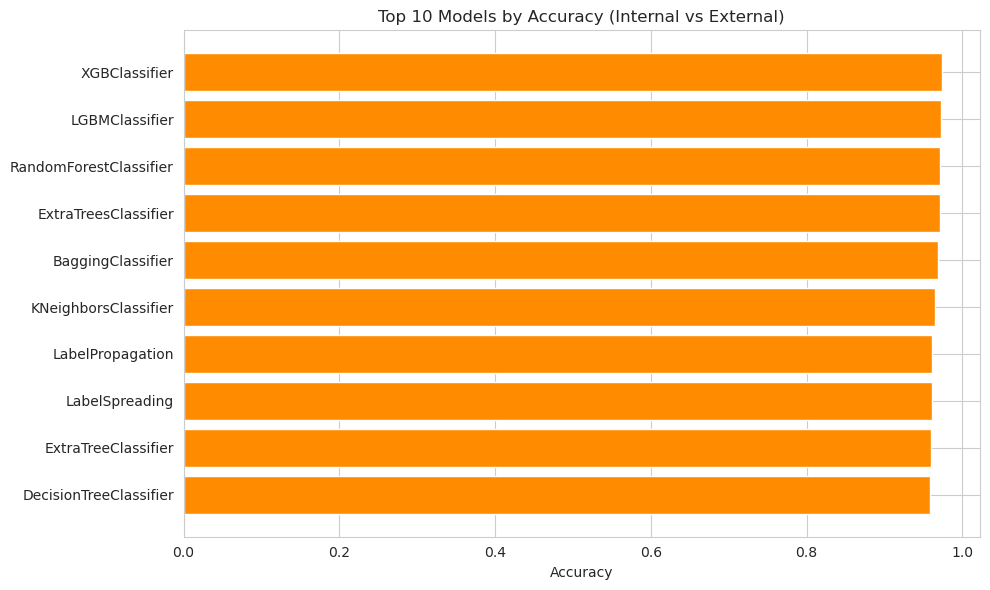

In [35]:
# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
top_clf3 = clf3_models.head(10).sort_values('Accuracy', ascending=True)
ax.barh(top_clf3.index, top_clf3['Accuracy'], color='darkorange')
ax.set_xlabel('Accuracy')
ax.set_title('Top 10 Models by Accuracy (Internal vs External)')
plt.tight_layout()
plt.show()

## 10. Summary

In [36]:
# Summary
print("\n" + "="*70)
print("📊 LAZYPREDICT ANALYSIS SUMMARY")
print("="*70)

print("\n✅ Preprocessing Pipeline (korrekte Reihenfolge):")
print("   1. Train-Test-Split")
print("   2. Imputer fit auf Train → transform auf Train & Test")
print("   3. Scaler fit auf Train → transform auf Train & Test")

print("\n" + "-"*70)

print("\n🔷 REGRESSION - Total Workflow Time:")
print(f"   Best Model: {reg_models.index[0]}")
print(f"   R² Score:   {reg_models['R-Squared'].iloc[0]:.4f}")
print(f"   RMSE:       {reg_models['RMSE'].iloc[0]:.4f}")

print("\n🔷 CLASSIFICATION - Issue Priority:")
print(f"   Best Model:        {clf_models.index[0]}")
print(f"   Accuracy:          {clf_models['Accuracy'].iloc[0]:.4f}")
print(f"   Balanced Accuracy: {clf_models['Balanced Accuracy'].iloc[0]:.4f}")

print("\n🔷 CLASSIFICATION - Issue Resolution:")
print(f"   Best Model:        {clf2_models.index[0]}")
print(f"   Accuracy:          {clf2_models['Accuracy'].iloc[0]:.4f}")
print(f"   Balanced Accuracy: {clf2_models['Balanced Accuracy'].iloc[0]:.4f}")

print("\n🔷 CLASSIFICATION - Project Type:")
print(f"   Best Model:        {clf3_models.index[0]}")
print(f"   Accuracy:          {clf3_models['Accuracy'].iloc[0]:.4f}")
print(f"   Balanced Accuracy: {clf3_models['Balanced Accuracy'].iloc[0]:.4f}")

print("\n" + "="*70)


📊 LAZYPREDICT ANALYSIS SUMMARY

✅ Preprocessing Pipeline (korrekte Reihenfolge):
   1. Train-Test-Split
   2. Imputer fit auf Train → transform auf Train & Test
   3. Scaler fit auf Train → transform auf Train & Test

----------------------------------------------------------------------

🔷 REGRESSION - Total Workflow Time:
   Best Model: LGBMRegressor
   R² Score:   0.9866
   RMSE:       0.3657

🔷 CLASSIFICATION - Issue Priority:
   Best Model:        NearestCentroid
   Accuracy:          0.3596
   Balanced Accuracy: 0.3638

🔷 CLASSIFICATION - Issue Resolution:
   Best Model:        NearestCentroid
   Accuracy:          0.4797
   Balanced Accuracy: 0.4472

🔷 CLASSIFICATION - Project Type:
   Best Model:        XGBClassifier
   Accuracy:          0.9738
   Balanced Accuracy: 0.9675



In [37]:
# Save results
output_dir = directory.parent / 'results'
output_dir.mkdir(parents=True, exist_ok=True)

reg_models.to_csv(output_dir / 'lazypredict_regression.csv')
clf_models.to_csv(output_dir / 'lazypredict_priority.csv')
clf2_models.to_csv(output_dir / 'lazypredict_resolution.csv')
clf3_models.to_csv(output_dir / 'lazypredict_project_type.csv')

print(f"✓ Results saved to: {output_dir}")

✓ Results saved to: ../data/results
